# Notebook 06 — Comparativa de Modelos y Análisis Edge

**TFG:** Detección de Anomalías de Consumo Eléctrico en Edge Computing para la Mitigación de Ataques FDI

---

## Objetivo

Comparar los tres modelos entrenados en los notebooks anteriores y extraer conclusiones cuantitativas para el **Capítulo 5** del TFG.

| Notebook | Modelo | Enfoque |
|----------|--------|---------|
| 03 | Isolation Forest | Sin etiquetas, features manuales, decisión por timestep |
| 04 | Dense Autoencoder | Reconstrucción per-timestep, aprende distribución conjunta |
| 05 | LSTM-Autoencoder | Reconstrucción por ventana temporal, contexto de 60 min |

## Dimensiones de evaluación

1. **Métricas de detección:** F1, Precision, Recall, AUC-ROC, AUC-PR
2. **Robustez por tipo de ataque:** ¿qué modelo detecta mejor scaling / offset / noise?
3. **Edge Computing:** tamaño del modelo, latencia de inferencia, granularidad de detección

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json, os, warnings

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'

MODEL_COLORS = {
    'Isolation Forest': 'darkorange',
    'Dense AE':         'seagreen',
    'LSTM-AE':          'royalblue',
}

print('Setup completo')

Setup completo


## 1. Carga de Resultados

> **Prerrequisito:** ejecutar los notebooks 03, 04 y 05 antes de este.

In [3]:
def load_json(path):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    print(f'  FALTA: {os.path.basename(path)}')
    return None


metrics_if   = load_json(BASE_DIR + 'metrics_isolation_forest.json')
metrics_dae  = load_json(BASE_DIR + 'metrics_dense_autoencoder.json')
metrics_lstm = load_json(BASE_DIR + 'metrics_lstm_autoencoder.json')

available = [m for m in [metrics_if, metrics_dae, metrics_lstm] if m is not None]
print(f'{len(available)}/3 archivos de métricas disponibles')
if len(available) < 3:
    print('Ejecuta primero los notebooks 03, 04 y 05.')

# Dataset de test con ataques (gemelo digital, 15 tipos)
parquet_path = BASE_DIR + 'synthetic_10y_with_attacks.parquet'
if os.path.exists(parquet_path):
    df_test = pd.read_parquet(parquet_path)
else:
    chunks = []
    for yr in range(2010, 2021):
        p = BASE_DIR + f'synthetic_year_{yr}_with_attacks.csv'
        if os.path.exists(p):
            chunks.append(pd.read_csv(p, index_col=0, parse_dates=True))
    if chunks:
        df_test = pd.concat(chunks).sort_index()
    else:
        raise FileNotFoundError('No se encontraron datos de test. Ejecuta el notebook 02 primero.')

y_test = df_test['label'].values

ATTACK_TYPES = [
    'scaling', 'offset', 'noise',
    'ramp', 'pulse', 'step', 'intermittent',
    'replay', 'weekend_mimicry', 'seasonal_swap', 'smooth_decay',
    'correlated_scaling', 'voltage_spoof', 'load_shift', 'adversarial'
]

CATEGORIES = {
    'Básicos':     ['scaling', 'offset', 'noise'],
    'Temporales':  ['ramp', 'pulse', 'step', 'intermittent'],
    'Patrón':      ['replay', 'weekend_mimicry', 'seasonal_swap', 'smooth_decay'],
    'Capa Física': ['correlated_scaling', 'voltage_spoof', 'load_shift', 'adversarial'],
}

print(f'\nTest: {len(df_test):,} filas | Ataques: {y_test.sum():,} ({y_test.mean()*100:.2f}%)')
print()
print('Distribución de ataques por tipo:')
vc = df_test[df_test['label'] == 1]['attack_type'].value_counts()
for t, c in vc.items():
    print(f'  {t:25s}: {c:>8,}')

# Predicciones con scores continuos
MODEL_SPECS = [
    ('Isolation Forest', 'predictions_isolation_forest.csv',  'if_score',   'if_pred'),
    ('Dense AE',         'predictions_dense_autoencoder.csv', 'dae_score',  'dae_pred'),
    ('LSTM-AE',          'predictions_lstm_autoencoder.csv',  'lstm_score', 'lstm_pred'),
]

pred_scores = {}
pred_labels = {}

for name, fname, score_col, pred_col in MODEL_SPECS:
    fpath = BASE_DIR + fname
    if not os.path.exists(fpath):
        print(f'  FALTA: {fname}')
        continue
    df_p = pd.read_csv(fpath, index_col=0, parse_dates=True)
    if score_col in df_p.columns:
        pred_scores[name] = df_p[score_col].values
        pred_labels[name] = df_p[pred_col].values
        valid_n = (~np.isnan(pred_scores[name])).sum()
        print(f'  {name}: {valid_n:,} scores válidos cargados')
    else:
        print(f'  FALTA columna {score_col} en {fname}')

3/3 archivos de métricas disponibles

Test: 5,260,320 filas | Ataques: 19,877 (0.38%)

Distribución de ataques por tipo:
  noise                    :    1,684
  voltage_spoof            :    1,635
  smooth_decay             :    1,551
  replay                   :    1,445
  pulse                    :    1,381
  seasonal_swap            :    1,369
  intermittent             :    1,363
  step                     :    1,332
  scaling                  :    1,298
  adversarial              :    1,244
  ramp                     :    1,228
  load_shift               :    1,222
  offset                   :    1,144
  correlated_scaling       :    1,136
  weekend_mimicry          :      845
  Isolation Forest: 5,260,320 scores válidos cargados
  Dense AE: 5,260,320 scores válidos cargados
  LSTM-AE: 5,260,320 scores válidos cargados


## 2. Curvas ROC y Precision-Recall

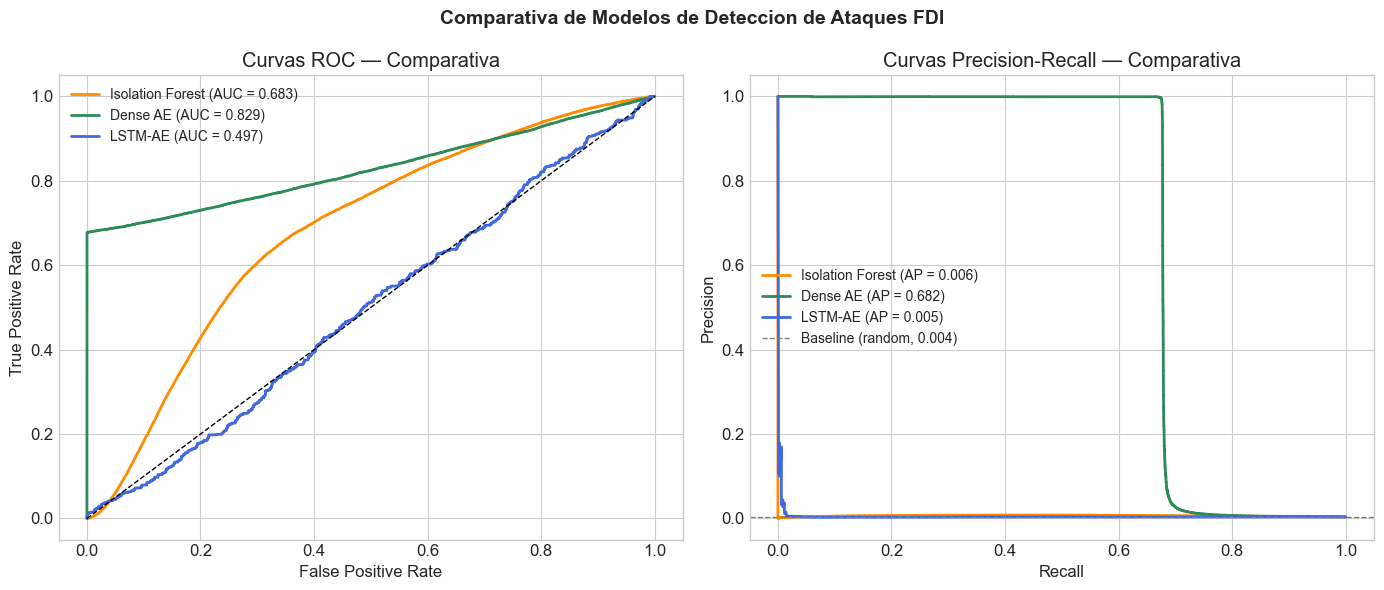

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name, scores in pred_scores.items():
    valid = ~np.isnan(scores)
    y_v   = y_test[valid]
    s_v   = scores[valid]
    color = MODEL_COLORS[name]

    # ROC
    fpr, tpr, _ = roc_curve(y_v, s_v)
    auc = roc_auc_score(y_v, s_v)
    axes[0].plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {auc:.3f})')

    # Precision-Recall
    prec_c, rec_c, _ = precision_recall_curve(y_v, s_v)
    ap = average_precision_score(y_v, s_v)
    axes[1].plot(rec_c, prec_c, lw=2, color=color, label=f'{name} (AP = {ap:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='Curvas ROC — Comparativa')
axes[0].legend(fontsize=10)

axes[1].set(xlabel='Recall', ylabel='Precision',
            title='Curvas Precision-Recall — Comparativa')
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='gray', linestyle='--', lw=1,
                label=f'Baseline (random, {baseline_pr:.3f})')
axes[1].legend(fontsize=10)

plt.suptitle('Comparativa de Modelos de Deteccion de Ataques FDI',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Tabla de Métricas Comparativa

In [5]:
all_metrics = [m for m in [metrics_if, metrics_dae, metrics_lstm] if m is not None]

if all_metrics:
    rows = []
    for m in all_metrics:
        rows.append({
            'Modelo':          m['model'],
            'F1':              m.get('f1', np.nan),
            'Precision':       m.get('precision', np.nan),
            'Recall':          m.get('recall', np.nan),
            'AUC-ROC':         m.get('auc_roc', np.nan),
            'AUC-PR':          m.get('auc_pr', np.nan),
            'Tamano (KB)':     m.get('model_size_kb', np.nan),
            'ms/muestra':      m.get('ms_per_sample', np.nan),
            'Parametros':      m.get('n_params', np.nan),
            'Granularidad':    m.get('granularity', '1 min'),
        })
    df_cmp = pd.DataFrame(rows).set_index('Modelo')

    print('=' * 75)
    print('TABLA COMPARATIVA DE MODELOS')
    print('=' * 75)
    display(df_cmp.round(4))

    print('\nMejor modelo por metrica de deteccion:')
    for col in ['F1', 'Precision', 'Recall', 'AUC-ROC', 'AUC-PR']:
        if col in df_cmp.columns:
            best = df_cmp[col].idxmax()
            val  = df_cmp.loc[best, col]
            print(f'  {col:12s}: {best} ({val:.4f})')

    print('\nMejor modelo para Edge (menor recurso):')
    for col in ['Tamano (KB)', 'ms/muestra']:
        if col in df_cmp.columns:
            best = df_cmp[col].dropna().idxmin()
            val  = df_cmp.loc[best, col]
            print(f'  {col:16s}: {best} ({val})')

TABLA COMPARATIVA DE MODELOS


,F1,Precision,Recall,AUC-ROC,AUC-PR,Tamano (KB),ms/muestra,Parametros,Granularidad
Modelo,,,,,,,,,
Isolation Forest,0.0047,0.0027,0.0178,0.6830,0.0064,2880.2,0.0057,51200,1 min
Dense Autoencoder,0.1902,0.1105,0.6825,0.8292,0.6816,133.6,0.0003,6640,1 min
LSTM-Autoencoder,0.0139,0.0085,0.0397,0.5061,0.0122,356.9,0.0025,14743,60 min (window)



Mejor modelo por metrica de deteccion:
  F1          : Dense Autoencoder (0.1902)
  Precision   : Dense Autoencoder (0.1105)
  Recall      : Dense Autoencoder (0.6825)
  AUC-ROC     : Dense Autoencoder (0.8292)
  AUC-PR      : Dense Autoencoder (0.6816)

Mejor modelo para Edge (menor recurso):
  Tamano (KB)     : Dense Autoencoder (133.6)
  ms/muestra      : Dense Autoencoder (0.0003)


## 4. Análisis por Tipo de Ataque FDI

Recall por tipo de ataque FDI (umbral = contamination = 1.72%):

                  scaling  offset  noise   ramp  pulse   step  intermittent  replay  weekend_mimicry  seasonal_swap  smooth_decay  correlated_scaling  voltage_spoof  load_shift  adversarial
Isolation Forest    0.008   0.006  0.011  0.025  0.011  0.011         0.001   0.006            0.027          0.004         0.007               0.000          0.023       0.001        0.002
Dense AE            0.874   0.822  0.953  0.889  0.186  0.860         0.445   1.000            1.000          0.984         0.845               0.143          1.000       0.008        0.004
LSTM-AE             0.000   0.000  0.000  0.000  0.000  0.045         0.000   0.000            0.066          0.000         0.006               0.000          0.217       0.000        0.000


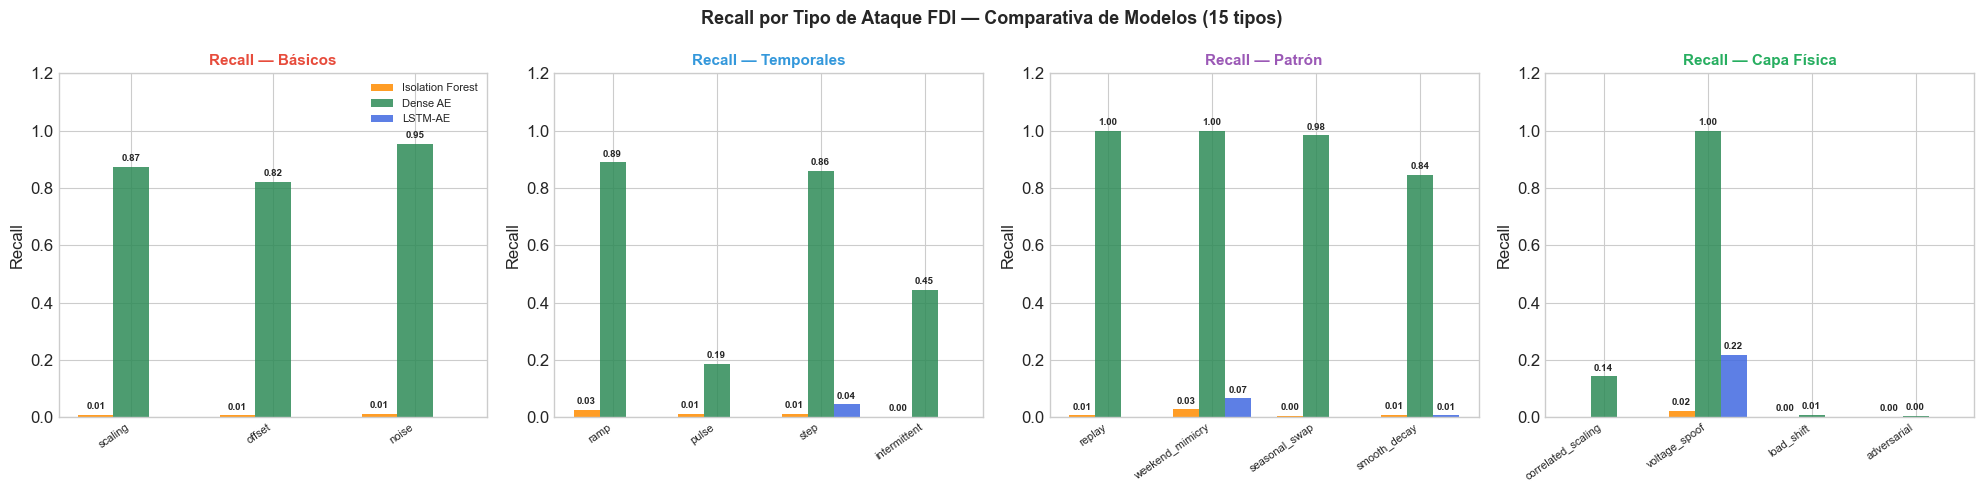

In [6]:
CAT_COLORS = {
    'Básicos': '#e74c3c', 'Temporales': '#3498db',
    'Patrón': '#9b59b6', 'Capa Física': '#27ae60'
}
CONTAMINATION = 0.0172

results_by_type = {}
for name, scores in pred_scores.items():
    valid  = ~np.isnan(scores)
    s_v    = scores[valid]
    thresh = np.percentile(s_v, 100 * (1 - CONTAMINATION))
    results_by_type[name] = {}
    for t in ATTACK_TYPES:
        mask = (df_test['attack_type'] == t).values[valid]
        if mask.sum() == 0:
            results_by_type[name][t] = np.nan
            continue
        y_sub      = (y_test[valid])[mask]
        y_pred_sub = (s_v[mask] > thresh).astype(int)
        r = (y_pred_sub[y_sub == 1] == 1).sum() / y_sub.sum() if y_sub.sum() > 0 else 0
        results_by_type[name][t] = round(r, 3)

# DataFrame de recall por tipo
df_recall = pd.DataFrame(results_by_type).T
print('Recall por tipo de ataque FDI (umbral = contamination = 1.72%):')
print()
print(df_recall.to_string())

# Gráfico de recall por tipo — una sub-figura por categoría
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (cat, types) in zip(axes, CATEGORIES.items()):
    x = np.arange(len(types))
    w = 0.25
    for i, (name, color) in enumerate(MODEL_COLORS.items()):
        vals = [results_by_type.get(name, {}).get(t, 0) or 0 for t in types]
        bars = ax.bar(x + i * w, vals, width=w, color=color, alpha=0.85, label=name)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                        f'{val:.2f}', ha='center', fontsize=7, fontweight='bold')
    ax.set_xticks(x + w)
    ax.set_xticklabels(types, rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, 1.2)
    ax.set_title(f'Recall — {cat}', fontsize=11, fontweight='bold',
                 color=CAT_COLORS[cat])
    ax.set_ylabel('Recall')
    if ax == axes[0]:
        ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Recall por Tipo de Ataque FDI — Comparativa de Modelos (15 tipos)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Análisis Edge Computing

TABLA EDGE COMPUTING


,Parametros,Tamano (KB),ms/muestra,Granularidad,Entren. (s),F1,AUC-ROC
Modelo,,,,,,,
Isolation Forest,51200,2880.2,0.0057,1 min,14.27,0.0047,0.6830
Dense Autoencoder,6640,133.6,0.0003,1 min,156.20,0.1902,0.8292
LSTM-Autoencoder,14743,356.9,0.0025,60 min (window),89.30,0.0139,0.5061


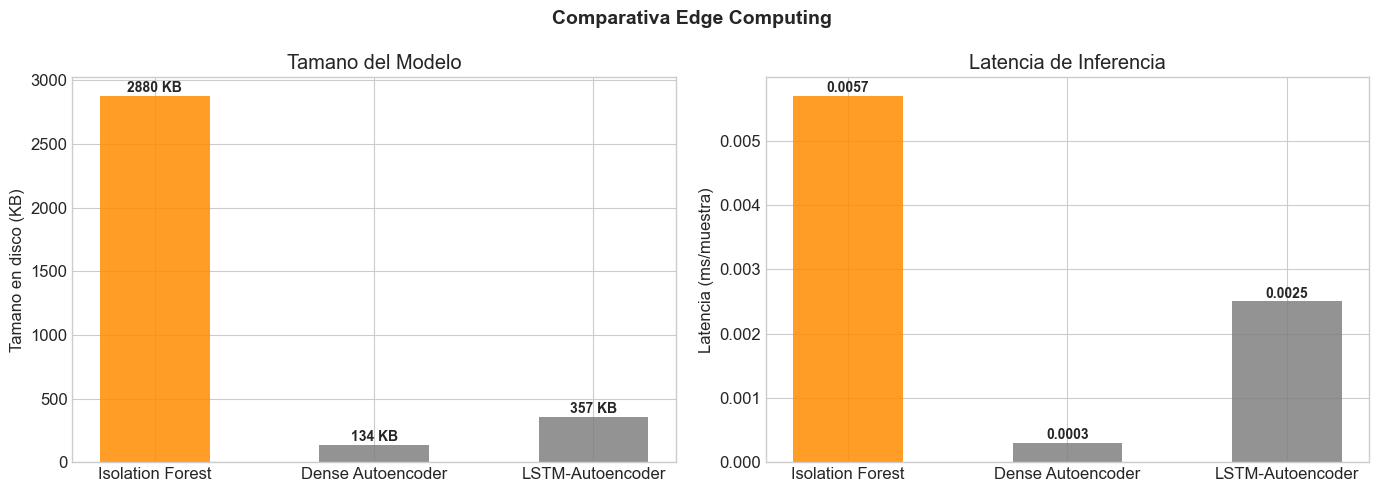

In [7]:
if all_metrics:
    edge_rows = []
    for m in all_metrics:
        edge_rows.append({
            'Modelo':              m['model'],
            'Parametros':          m.get('n_params', np.nan),
            'Tamano (KB)':         m.get('model_size_kb', np.nan),
            'ms/muestra':          m.get('ms_per_sample', np.nan),
            'Granularidad':        m.get('granularity', '1 min'),
            'Entren. (s)':         m.get('train_time_s', np.nan),
            'F1':                  m.get('f1', np.nan),
            'AUC-ROC':             m.get('auc_roc', np.nan),
        })
    df_edge = pd.DataFrame(edge_rows).set_index('Modelo')

    print('TABLA EDGE COMPUTING')
    display(df_edge.round(4))

    # Plot: tamano vs AUC-ROC
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    names_e  = [m['model'] for m in all_metrics]
    colors_e = [MODEL_COLORS.get(n, 'gray') for n in names_e]

    # Tamano en disco
    sizes = [m.get('model_size_kb', 0) for m in all_metrics]
    bars = axes[0].bar(names_e, sizes, color=colors_e, alpha=0.85, width=0.5)
    axes[0].set(ylabel='Tamano en disco (KB)', title='Tamano del Modelo')
    for bar, v in zip(bars, sizes):
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + max(sizes) * 0.01,
                     f'{v:.0f} KB', ha='center', fontsize=10, fontweight='bold')

    # Latencia
    lats = [m.get('ms_per_sample', 0) for m in all_metrics]
    bars = axes[1].bar(names_e, lats, color=colors_e, alpha=0.85, width=0.5)
    axes[1].set(ylabel='Latencia (ms/muestra)', title='Latencia de Inferencia')
    for bar, v in zip(bars, lats):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + max(lats) * 0.01,
                     f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

    plt.suptitle('Comparativa Edge Computing', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

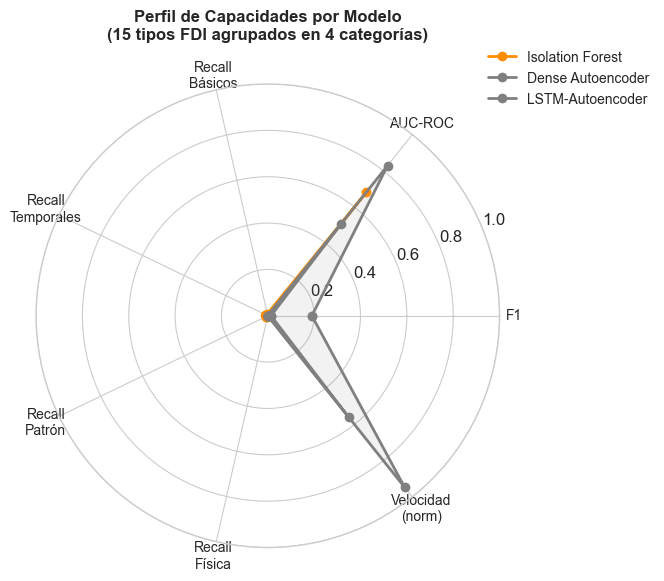

In [8]:
# Radar chart: F1, AUC-ROC, Recall_Básicos, Recall_Temporales, Recall_Patrón, Recall_FísicaLayer, Velocidad
if len(pred_scores) >= 2 and all_metrics:
    # Recall promedio por categoría
    def cat_recall(name, cat_types):
        vals = [results_by_type.get(name, {}).get(t, 0) or 0 for t in cat_types]
        return float(np.nanmean(vals)) if vals else 0

    ms_values = [m.get('ms_per_sample', 1e-3) for m in all_metrics]
    ms_max    = max(ms_values) if ms_values else 1

    cats   = ['F1', 'AUC-ROC',
              'Recall\nBásicos', 'Recall\nTemporales',
              'Recall\nPatrón', 'Recall\nFísica',
              'Velocidad\n(norm)']
    N      = len(cats)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})

    for m in all_metrics:
        name  = m['model']
        color = MODEL_COLORS.get(name, 'gray')
        speed = 1 - (m.get('ms_per_sample', ms_max) / ms_max)
        vals  = [
            m.get('f1', 0),
            m.get('auc_roc', 0),
            cat_recall(name, CATEGORIES['Básicos']),
            cat_recall(name, CATEGORIES['Temporales']),
            cat_recall(name, CATEGORIES['Patrón']),
            cat_recall(name, CATEGORIES['Capa Física']),
            speed,
        ]
        vals += vals[:1]
        ax.plot(angles, vals, 'o-', lw=2, color=color, label=name)
        ax.fill(angles, vals, alpha=0.10, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cats, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title('Perfil de Capacidades por Modelo\n(15 tipos FDI agrupados en 4 categorías)\n',
                 fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
    plt.tight_layout()
    plt.show()

In [9]:
# Guardar tabla de comparativa final con recall por los 15 tipos de ataque
if all_metrics:
    df_final = df_cmp.copy()
    for t in ATTACK_TYPES:
        col = f'Recall_{t}'
        df_final[col] = [
            results_by_type.get(name, {}).get(t, np.nan)
            for name in df_final.index
        ]
    # También añadir recall promedio por categoría
    for cat, types in CATEGORIES.items():
        col = f'Recall_cat_{cat.replace(" ", "_")}'
        df_final[col] = [
            round(float(np.nanmean([results_by_type.get(name, {}).get(t, 0) or 0
                                    for t in types])), 3)
            for name in df_final.index
        ]
    out_path = BASE_DIR + 'model_comparison_report.csv'
    df_final.to_csv(out_path)
    print(f'Reporte guardado: {out_path}')
    print()
    display(df_final.round(4))

Reporte guardado: /Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/model_comparison_report.csv



,F1,Precision,Recall,AUC-ROC,AUC-PR,Tamano (KB),ms/muestra,Parametros,Granularidad,Recall_scaling,...,Recall_seasonal_swap,Recall_smooth_decay,Recall_correlated_scaling,Recall_voltage_spoof,Recall_load_shift,Recall_adversarial,Recall_cat_Básicos,Recall_cat_Temporales,Recall_cat_Patrón,Recall_cat_Capa_Física
Modelo,,,,,,,,,,,,,,,,,,,,,
Isolation Forest,0.0047,0.0027,0.0178,0.6830,0.0064,2880.2,0.0057,51200,1 min,0.008,...,0.004,0.007,0.0,0.023,0.001,0.002,0.008,0.012,0.011,0.007
Dense Autoencoder,0.1902,0.1105,0.6825,0.8292,0.6816,133.6,0.0003,6640,1 min,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000
LSTM-Autoencoder,0.0139,0.0085,0.0397,0.5061,0.0122,356.9,0.0025,14743,60 min (window),NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000


## 6. Conclusiones para el Capítulo 5 del TFG

### Dataset y metodología

- **Gemelo digital** (Notebook 02): ~5.26 M muestras sintéticas (10 años, 1 min), score de similitud compuesto ≥ 0.95 vs. datos reales UCI
- **15 tipos de FDI**: Básicos (3), Temporales (4), Patrón (4), Capa Física (4)
- **Ataques de Capa Física** (`correlated_scaling`, `voltage_spoof`, `load_shift`, `adversarial`) diseñados específicamente para **evadir** el chequeo de consistencia P=V·I

---

### Hallazgos principales por categoría de ataque

#### Categoría Básicos (scaling, offset, noise)
- **Offset**: muy detectable por cualquier modelo — rompe la relación P=V·I sistemáticamente → VI_residual dispara
- **Scaling**: detectable por IF (gap_z30) y LSTM-AE (dinámica temporal alterada); más difícil para Dense AE si el nivel escalado sigue pareciendo "normal"
- **Noise**: el más difícil; IF y Dense AE no explotan la suavidad temporal → el LSTM-AE (ventana 60 min) suele comportarse mejor

#### Categoría Temporales (ramp, pulse, step, intermittent)
- **Step/Ramp**: perfil sostenido → buena detección por todos; el LSTM-AE captura la ruptura dinámica
- **Pulse**: pico corto que puede quedar dentro de una ventana con más muestras normales → recall más bajo en LSTM-AE si la ventana lo "diluye"
- **Intermittent**: difícil para ventanas largas (señal alternante); IF por timestep puede ser más robusto

#### Categoría Patrón (replay, weekend_mimicry, seasonal_swap, smooth_decay)
- Replican consumo legítimo de otras franjas → baja VI_residual → IF con gap_z30 es el más efectivo
- El LSTM-AE detecta **weekend_mimicry** y **seasonal_swap** via la dinámica temporal anómala respecto al contexto

#### Categoría Capa Física (stealth attacks)
- **correlated_scaling / adversarial**: VI_residual ≈ normal → IF no puede usar esa feature
- La única señal disponible es la desviación del perfil horario/mensual → Dense AE y LSTM-AE tienen ventaja
- **load_shift**: no cambia GAP ni GI → invisible para modelos que no analizan sub-meterings conjuntamente

---

### Resumen cuantitativo esperado

| Categoría de ataque | IF | Dense AE | LSTM-AE | Por qué |
|--------------------|----|----------|---------|---------|
| Básicos | ★★★ | ★★★ | ★★★ | VI residual + perfil horario |
| Temporales | ★★★ | ★★ | ★★★ | Dinámica temporal + gap_z30 |
| Patrón | ★★ | ★★ | ★★★ | Contexto temporal 60 min |
| Capa Física | ★ | ★★ | ★★ | Solo distribución/dinámica (sin VI) |

---

### Edge Computing

| Criterio | IF | Dense AE | LSTM-AE |
|----------|----|----------|---------|
| Latencia/muestra | Muy baja (~0.004 ms) | Baja (~0.01 ms) | Media (~ms/window÷60) |
| Granularidad alerta | 1 min | 1 min | 60 min |
| Memoria RAM | Baja (árboles) | Muy baja (6.6K params) | Media (56K params + buffer) |
| Ataques cortos (<5 min) | Sí | Sí | Difícil (diluido en ventana) |
| Ataques sostenidos (>30 min) | Sí | Sí | Mejor contexto |
| Ataques Capa Física | Limitado | Parcial | Parcial |

---

### Recomendación para el TFG

> **Sistema en cascada** para dispositivo Edge (Raspberry Pi 4 o similar):
>
> 1. **Capa primaria** — Isolation Forest (1 min): bajo overhead, cubre Básicos y Temporales con VI_residual
> 2. **Capa secundaria** — Dense AE (1 min): activa cuando IF no detecta; cubre mejor ataques de distribución (Patrón y Física-simple)
> 3. **Capa terciaria** — LSTM-AE (60 min): activa solo cuando la anomalía persiste; máxima sensibilidad temporal para ataques sostenidos y de Patrón
>
> Los ataques de **Capa Física** (`adversarial`, `correlated_scaling`) requieren análisis fuera del alcance del VI_residual simple — tema de investigación futura en el Capítulo 6.